# Single-Feature Clustering and Robustness Sweep — 70B (position-residualised)

**Purpose:**
1. Residualise all L1 features against `prompt_index` (removes execution-position confound).
2. Run a single-feature sweep over residualised features to identify the best discriminating feature.
3. Run a robustness sweep on that best residualised feature: for each subset size x, repeatedly
   draw x/2 emotional and x/2 neutral prompts per run, run k-means on the residualised feature,
   and record accuracy. Plot mean ± 1 SD vs x.

**Why residualise:**
Prompt index is assigned sequentially within a batch; any monotonic hardware trend (thermal
throttling, power state ramp-up) could confound condition differences. Residualising removes
the linear prompt-index effect before clustering.

## §1 — Imports and configuration

In [22]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
DATA_DIR   = BASE_DIR / 'data' / 'longer70b'
RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
RUNS = ['219a', '219b', '219c', '220a', '233a', '233c']

# ── L1 indicators ─────────────────────────────────────────────────────────────
L1_INDICATORS = [
    #'hat_TLB',
    #'tlb:tlb_flush',
    'core_power.throttle',
]

# ── Robustness sweep config ────────────────────────────────────────────────────
SUBSET_SIZES = [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
N_REPEATS    = 20
N_INIT       = 50
RAND_SEED    = 42

print('Configuration OK')
print(f'  Runs         : {RUNS}')
print(f'  Subset sizes : {SUBSET_SIZES}')
print(f'  Repeats      : {N_REPEATS}')


Configuration OK
  Runs         : ['219a', '219b', '219c', '220a', '233a', '233c']
  Subset sizes : [22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
  Repeats      : 20


## §2 — Load data

In [23]:
dfs = []
runs_loaded = []
for run in RUNS:
    for stem in [f'blocks{run}', run]:
        p = DATA_DIR / f'{stem}.csv'
        if p.exists():
            d = pd.read_csv(p)
            d['run'] = run
            dfs.append(d)
            runs_loaded.append(run)
            break
    else:
        print(f'  WARNING: no CSV found for run {run}')

assert dfs, 'No data loaded. Check DATA_DIR and RUNS.'
df_all = pd.concat(dfs, ignore_index=True)
df_all['label'] = (df_all['condition'] == 'emotional').astype(int)

print(f'Loaded {len(runs_loaded)} runs: {runs_loaded}')
print(f'  Total trials : {len(df_all)}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')


Loaded 6 runs: ['219a', '219b', '219c', '220a', '233a', '233c']
  Total trials : 240
  Emotional    : 120
  Neutral      : 120


elapsed_ms mean:  62154.11868574584
elapsed_ms std:  2515.9799573520054
elapsed_ms median:  62038.460716
elapsed_ms min:  56557.241608
elapsed_ms max:  70250.855178


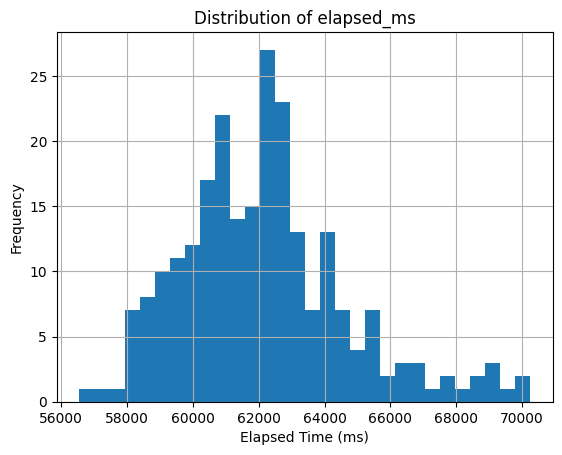

In [24]:
print("elapsed_ms mean: ", df_all['elapsed_ms'].mean())
print("elapsed_ms std: ", df_all['elapsed_ms'].std())
print("elapsed_ms median: ", df_all['elapsed_ms'].median())
print("elapsed_ms min: ", df_all['elapsed_ms'].min())
print("elapsed_ms max: ", df_all['elapsed_ms'].max())

plot = df_all['elapsed_ms'].hist(bins=30)
plot.set_title('Distribution of elapsed_ms')
plot.set_xlabel('Elapsed Time (ms)')
plot.set_ylabel('Frequency')
plt.show()

## §3 — Select L1 features

In [25]:
def indicator_of(col):
    for ind in L1_INDICATORS:
        if col.startswith(ind + '__'):
            return ind
    return ''

l1_cols = [c for c in df_all.columns if indicator_of(c) in L1_INDICATORS]

X_l1 = df_all[l1_cols].copy()
X_l1 = X_l1.dropna(axis=1, how='all')
X_l1 = X_l1.fillna(X_l1.median())
X_l1 = X_l1.loc[:, X_l1.std() > 0]
#X_l1 = X_l1[["core_power.throttle__mean_rate", "core_power.throttle__burst_rate", "core_power.throttle__lz_complexity", "core_power.throttle__slope", "core_powe.throttle__"]]
print(f'L1 features available: {X_l1.shape[1]}')


L1 features available: 10


In [26]:
# Residualise against prompt_index only
# elapsed_ms is NOT used: it differs significantly between conditions (p=0.037)
# and is therefore a potential mediator, not a pure confound

cov_pos = df_all['prompt_index'].values.astype(float)

# Quick diagnostic: elapsed_ms by condition (for reference)
for cond in ['emotional', 'neutral']:
    v = df_all.loc[df_all.condition == cond, 'elapsed_ms']
    print(f'  {cond:10s}  elapsed_ms: mean={v.mean():.0f}  std={v.std():.0f}  median={v.median():.0f}')

from scipy.stats import mannwhitneyu
e = df_all[df_all.condition == 'emotional']['elapsed_ms'].dropna()
n = df_all[df_all.condition == 'neutral']['elapsed_ms'].dropna()
_, p_ms = mannwhitneyu(e, n, alternative='two-sided')
print(f'  elapsed_ms condition difference: p={p_ms:.4f} — {"excluded from residualisation (mediator)" if p_ms < 0.05 else "not significant"}')
print()

# Residualise all L1 features against prompt_index only
X_l1_resid = X_l1.copy()
for col in X_l1.columns:
    y_col = X_l1[col].values.astype(float)
    slope, intercept, _, _, _ = linregress(cov_pos, y_col)
    X_l1_resid[col] = y_col - (slope * cov_pos + intercept)

print(f'Residualised all L1 features against prompt_index only.')
print(f'Features: {X_l1_resid.shape[1]}')
print(f'Residual means (should be ~0): min={X_l1_resid.mean().min():.6f}  max={X_l1_resid.mean().max():.6f}')

  emotional   elapsed_ms: mean=62156  std=3049  median=61605
  neutral     elapsed_ms: mean=62152  std=1849  median=62198
  elapsed_ms condition difference: p=0.1726 — not significant

Residualised all L1 features against prompt_index only.
Features: 10
Residual means (should be ~0): min=-0.001400  max=0.000000


# CHECK

## §5 — Single-feature sweep on residualised features

In [27]:
MAJORITY_THRESHOLD = 0.75   # require ≥ 75% of valid runs to agree on direction

def kmeans_acc_ari(X, y, n_init=50, seed=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    km = KMeans(n_clusters=2, n_init=n_init, random_state=seed)
    pred = km.fit_predict(Xs)
    cm = confusion_matrix(y, pred)
    if cm.shape != (2, 2):
        return 0.5, 0.0
    acc = max(
        (cm[0,0] + cm[1,1]) / cm.sum(),
        (cm[0,1] + cm[1,0]) / cm.sum()
    )
    ari = adjusted_rand_score(y, pred)
    return float(acc), float(ari)


y_true = df_all['label'].values
runs_unique = df_all['run'].unique()

records_resid = []
for col in X_l1_resid.columns:
    acc, ari = kmeans_acc_ari(X_l1_resid[[col]].values, y_true,
                              n_init=N_INIT, seed=RAND_SEED)
    e_mean = X_l1_resid.loc[df_all['condition'] == 'emotional', col].mean()
    n_mean = X_l1_resid.loc[df_all['condition'] == 'neutral',   col].mean()
    direction = '↑E' if e_mean > n_mean else '↑N'

    run_dirs = []
    for run in runs_unique:
        mask_run = df_all['run'] == run
        e_run = X_l1_resid.loc[mask_run & (df_all['condition'] == 'emotional'), col].mean()
        n_run = X_l1_resid.loc[mask_run & (df_all['condition'] == 'neutral'),   col].mean()
        if not (np.isnan(e_run) or np.isnan(n_run)):
            run_dirs.append('↑E' if e_run > n_run else '↑N')

    majority_dir    = max(set(run_dirs), key=run_dirs.count) if run_dirs else '?'
    n_runs_majority = sum(1 for d in run_dirs if d == majority_dir)
    n_runs_valid    = len(run_dirs)
    majority_frac   = n_runs_majority / n_runs_valid if n_runs_valid > 0 else 0.0

    records_resid.append({
        'feature':          col,
        'indicator':        indicator_of(col),
        'metric':           col.split('__')[-1],
        'accuracy':         acc,
        'ari':              ari,
        'direction':        direction,
        'runs_majority':    f'{n_runs_majority}/{n_runs_valid}',
        'majority_frac':    majority_frac,
    })

sf_resid = pd.DataFrame(records_resid).sort_values('accuracy', ascending=False).reset_index(drop=True)

# Filter to features with ≥ 75% majority agreement
sf_resid_filtered = sf_resid[sf_resid['majority_frac'] >= MAJORITY_THRESHOLD].reset_index(drop=True)

BEST_FEATURE = sf_resid_filtered.iloc[0]['feature']
BEST_ACC     = sf_resid_filtered.iloc[0]['accuracy']
BEST_ARI     = sf_resid_filtered.iloc[0]['ari']

print(f'Majority threshold : ≥{MAJORITY_THRESHOLD:.0%} of valid runs')
print(f'Features passing   : {len(sf_resid_filtered)} / {len(sf_resid)}')
print()
print(f'Best single feature (residualised, ≥{MAJORITY_THRESHOLD:.0%} majority): {BEST_FEATURE}')
print(f'  Accuracy  : {BEST_ACC:.4f}')
print(f'  ARI       : {BEST_ARI:.4f}')
print(f'  Direction : {sf_resid_filtered.iloc[0]["direction"]}')
print()
print('All features (sorted by accuracy):')
print(sf_resid[['feature', 'accuracy', 'ari', 'direction', 'runs_majority', 'majority_frac']].to_string(index=False))
print()
print(f'Features passing ≥{MAJORITY_THRESHOLD:.0%} majority:')
print(sf_resid_filtered[['feature', 'accuracy', 'ari', 'direction', 'runs_majority']].to_string(index=False))

Majority threshold : ≥75% of valid runs
Features passing   : 6 / 10

Best single feature (residualised, ≥75% majority): core_power.throttle__slope
  Accuracy  : 0.6292
  ARI       : 0.0638
  Direction : ↑N

All features (sorted by accuracy):
                              feature  accuracy       ari direction runs_majority  majority_frac
           core_power.throttle__slope  0.629167  0.063766        ↑N           6/6       1.000000
core_power.throttle__spectral_entropy  0.625000  0.058650        ↑E           6/6       1.000000
         core_power.throttle__p90_p10  0.620833  0.054592        ↑N           6/6       1.000000
        core_power.throttle__variance  0.608333  0.042941        ↑N           6/6       1.000000
   core_power.throttle__lz_complexity  0.604167  0.041906        ↑E           6/6       1.000000
       core_power.throttle__mean_rate  0.575000  0.021364        ↑N           4/6       0.666667
          core_power.throttle__iat_cv  0.570833  0.018758        ↑E           5

In [28]:
from scipy.stats import mannwhitneyu

# ── Mann-Whitney U with Bonferroni correction on majority-passing features ────
print('Mann-Whitney U test with Bonferroni correction')
print(f'Features tested: {len(sf_resid_filtered)}')
alpha = 0.05
alpha_corrected = alpha / len(sf_resid_filtered) if len(sf_resid_filtered) > 0 else alpha
print(f'Bonferroni-corrected alpha: {alpha_corrected:.4f}')
print()

mwu_records = []
for _, row in sf_resid_filtered.iterrows():
    feat = row['feature']
    e_vals = X_l1_resid.loc[df_all['condition'] == 'emotional', feat].dropna()
    n_vals = X_l1_resid.loc[df_all['condition'] == 'neutral',   feat].dropna()
    u, p_raw = mannwhitneyu(e_vals, n_vals, alternative='two-sided')
    p_corrected = min(p_raw * len(sf_resid_filtered), 1.0)
    sig = p_corrected < alpha
    mwu_records.append({
        'feature':       feat,
        'direction':     row['direction'],
        'runs_majority': row['runs_majority'],
        'U':             u,
        'p_raw':         p_raw,
        'p_corrected':   p_corrected,
        'significant':   'YES' if sig else 'NO',
    })

mwu_df = pd.DataFrame(mwu_records)
print(mwu_df[['feature', 'direction', 'runs_majority',
              'U', 'p_raw', 'p_corrected', 'significant']].to_string(index=False))
print()
print('Note: test applied to position-residualised feature values.')
print(f'Bonferroni correction: p_raw × {len(sf_resid_filtered)} (number of features tested).')

Mann-Whitney U test with Bonferroni correction
Features tested: 6
Bonferroni-corrected alpha: 0.0083

                              feature direction runs_majority      U        p_raw  p_corrected significant
           core_power.throttle__slope        ↑N           6/6 4145.0 1.347705e-08 8.086228e-08         YES
core_power.throttle__spectral_entropy        ↑E           6/6 9967.0 2.684313e-07 1.610588e-06         YES
         core_power.throttle__p90_p10        ↑N           6/6 4299.0 6.908379e-08 4.145027e-07         YES
        core_power.throttle__variance        ↑N           6/6 5177.0 1.693172e-04 1.015903e-03         YES
   core_power.throttle__lz_complexity        ↑E           6/6 9307.0 8.962842e-05 5.377705e-04         YES
          core_power.throttle__iat_cv        ↑E           5/6 6527.0 2.111070e-01 1.000000e+00          NO

Note: test applied to position-residualised feature values.
Bonferroni correction: p_raw × 6 (number of features tested).


# RAW

In [29]:
# ── Non-residualised single-feature sweep ─────────────────────────────────────
print('Non-residualised single-feature sweep')
print(f'Features: {X_l1.shape[1]}')
print()

y_true = df_all['label'].values
runs_unique = df_all['run'].unique()

records_raw = []
for col in X_l1.columns:
    acc, ari = kmeans_acc_ari(X_l1[[col]].values, y_true,
                              n_init=N_INIT, seed=RAND_SEED)
    e_mean = X_l1.loc[df_all['condition'] == 'emotional', col].mean()
    n_mean = X_l1.loc[df_all['condition'] == 'neutral',   col].mean()
    direction = '↑E' if e_mean > n_mean else '↑N'

    run_dirs = []
    for run in runs_unique:
        mask_run = df_all['run'] == run
        e_run = X_l1.loc[mask_run & (df_all['condition'] == 'emotional'), col].mean()
        n_run = X_l1.loc[mask_run & (df_all['condition'] == 'neutral'),   col].mean()
        if not (np.isnan(e_run) or np.isnan(n_run)):
            run_dirs.append('↑E' if e_run > n_run else '↑N')

    majority_dir    = max(set(run_dirs), key=run_dirs.count) if run_dirs else '?'
    n_runs_majority = sum(1 for d in run_dirs if d == majority_dir)
    n_runs_valid    = len(run_dirs)
    majority_frac   = n_runs_majority / n_runs_valid if n_runs_valid > 0 else 0.0

    records_raw.append({
        'feature':       col,
        'accuracy':      acc,
        'ari':           ari,
        'direction':     direction,
        'runs_majority': f'{n_runs_majority}/{n_runs_valid}',
        'majority_frac': majority_frac,
    })

sf_raw = pd.DataFrame(records_raw).sort_values('accuracy', ascending=False).reset_index(drop=True)

print('All features (sorted by accuracy):')
print(sf_raw[['feature', 'accuracy', 'ari', 'direction', 'runs_majority']].to_string(index=False))
print()
print(f'Best feature: {sf_raw.iloc[0].feature}  acc={sf_raw.iloc[0].accuracy:.4f}  ARI={sf_raw.iloc[0].ari:.4f}  {sf_raw.iloc[0].direction}')

Non-residualised single-feature sweep
Features: 10

All features (sorted by accuracy):
                              feature  accuracy       ari direction runs_majority
         core_power.throttle__p90_p10  0.637500  0.071819        ↑N           6/6
core_power.throttle__spectral_entropy  0.633333  0.067296        ↑E           6/6
           core_power.throttle__slope  0.629167  0.063766        ↑N           6/6
   core_power.throttle__lz_complexity  0.604167  0.041906        ↑E           6/6
        core_power.throttle__variance  0.583333  0.023703        ↑N           6/6
       core_power.throttle__mean_rate  0.575000  0.021364        ↑N           4/6
          core_power.throttle__iat_cv  0.570833  0.018758        ↑E           5/6
    core_power.throttle__perm_entropy  0.541667  0.004116        ↑N           3/6
core_power.throttle__burst_clustering  0.529167 -0.000602        ↑E           4/6
      core_power.throttle__burst_rate  0.504167  0.000000        ↑E           4/6

Best featu

## §6 — Robustness sweep on the best residualised feature

For each subset size x and each of the 20 repeats:
- Draw x/2 emotional and x/2 neutral **prompt indices** uniformly at random.
- Select all trials matching those prompt indices.
- Residualise the feature against prompt_index **within the subset** (same linear fit
  applied to the subset to stay self-contained).
- Run k-means and record accuracy and ARI.

In [30]:
rng = np.random.default_rng(RAND_SEED)
results = []

for x in SUBSET_SIZES:
    half = x // 2
    assert half <= min(len(emotional_prompts), len(neutral_prompts)), \
        f'x/2={half} exceeds available prompts per condition'

    accs, aris = [], []
    # Replace the inner loop with this:
    for _ in range(N_REPEATS):
        e_sel = rng.choice(emotional_prompts, size=half, replace=False)
        n_sel = rng.choice(neutral_prompts,   size=half, replace=False)

        mask = (
            ((df_all.condition == 'emotional') & (df_all.prompt_index.isin(e_sel))) |
            ((df_all.condition == 'neutral')   & (df_all.prompt_index.isin(n_sel)))
        )
        # Use pre-computed residuals from full dataset — do NOT re-residualise
        X_sub = X_l1_resid.loc[mask, BEST_FEATURE].values.reshape(-1, 1)
        y_sub = df_all.loc[mask, 'label'].values

        if len(np.unique(y_sub)) < 2:
            continue

        acc, ari = kmeans_acc_ari(X_sub, y_sub, n_init=N_INIT, seed=RAND_SEED)
        accs.append(acc)
        aris.append(ari)
        
    results.append({
        'x':        x,
        'total':    x * len(runs_loaded),
        'mean_acc': np.mean(accs),
        'std_acc':  np.std(accs),
        'mean_ari': np.mean(aris),
        'std_ari':  np.std(aris),
    })
    print(f'  x={x:2d}  total={x*len(runs_loaded):4d}  '
          f'mean_acc={np.mean(accs):.4f}  ±{np.std(accs):.4f}  '
          f'mean_ARI={np.mean(aris):.4f}')

res = pd.DataFrame(results)


NameError: name 'emotional_prompts' is not defined

## §7 — Plot

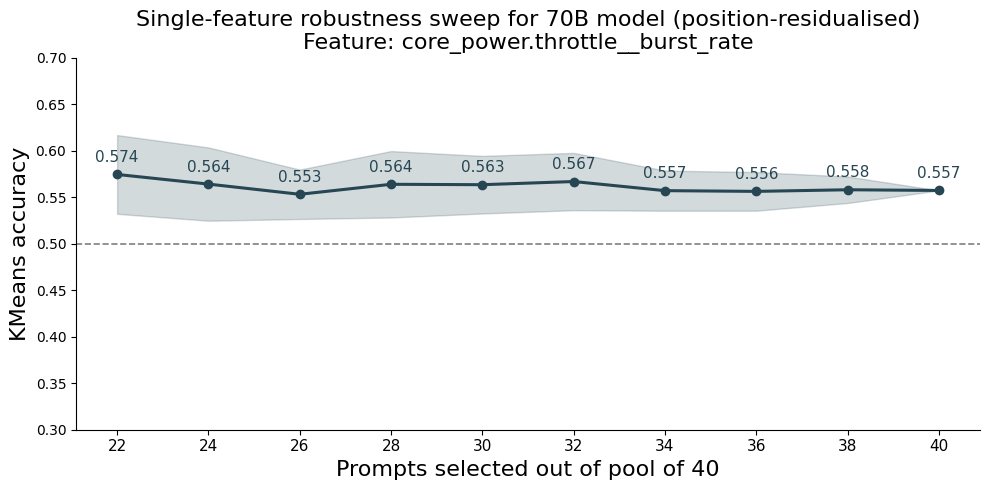

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/single_feature_robustness_70b_residualised.png


In [ ]:
COLOR = '#264653'

xs   = res['x'].values
mean = res['mean_acc'].values
std  = res['std_acc'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(xs, mean, marker='o', lw=2.2, color=COLOR, zorder=3,
        label=f'Best residualised feature: {BEST_FEATURE}')
ax.fill_between(xs, mean - std, mean + std,
                alpha=0.20, color=COLOR, label='± 1 SD across 20 repeats')

for xi, mi in zip(xs, mean):
    ax.annotate(f'{mi:.3f}', (xi, mi),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=11, color=COLOR)

ax.axhline(0.5, color='grey', lw=1.2, ls='--', label='Chance (0.50)')

ax.set_xlabel('Prompts selected out of pool of 40', fontsize=16)
ax.set_ylabel('KMeans accuracy', fontsize=16)
ax.set_title(
    f'Single-feature robustness sweep for 70B model (position-residualised)\n'
    f'Feature: {BEST_FEATURE}',
    fontsize=16
)
ax.set_xticks(xs)
ax.set_xticklabels([str(xi) for xi in xs], fontsize=11)
ax.set_ylim(0.3, 0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = RESULT_DIR / 'single_feature_robustness_70b_residualised.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## §8 — Summary table

In [ ]:
print('Single-feature robustness sweep — 70B (position-residualised)')
print(f'Best feature: {BEST_FEATURE}')
print(f'Full-dataset accuracy (x=40): {res[res.x==40].mean_acc.values[0]:.4f}')
print()
print(f'  {"x":>4}  {"total":>6}  {"mean acc":>9}  {"± SD":>7}  {"mean ARI":>9}  {"± SD":>7}')
print('-' * 60)
for _, r in res.iterrows():
    print(f'  {int(r.x):>4}  {int(r.total):>6}  {r.mean_acc:>9.4f}  '
          f'{r.std_acc:>7.4f}  {r.mean_ari:>9.4f}  {r.std_ari:>7.4f}')
print()
print('Chance baseline: 0.5000')


Single-feature robustness sweep — 70B (position-residualised)
Best feature: core_power.throttle__burst_rate
Full-dataset accuracy (x=40): 0.5571

     x   total   mean acc     ± SD   mean ARI     ± SD
------------------------------------------------------------
    22     154     0.5744   0.0423     0.0231   0.0281
    24     168     0.5640   0.0394     0.0169   0.0227
    26     182     0.5530   0.0265     0.0087   0.0127
    28     196     0.5638   0.0357     0.0165   0.0230
    30     210     0.5633   0.0309     0.0153   0.0164
    32     224     0.5667   0.0308     0.0173   0.0189
    34     238     0.5569   0.0216     0.0107   0.0107
    36     252     0.5562   0.0207     0.0105   0.0105
    38     266     0.5579   0.0142     0.0106   0.0069
    40     280     0.5571   0.0000     0.0096   0.0000

Chance baseline: 0.5000


## §9 — Distributions by condition — top features (after prompt_index + elapsed_ms residualisation)

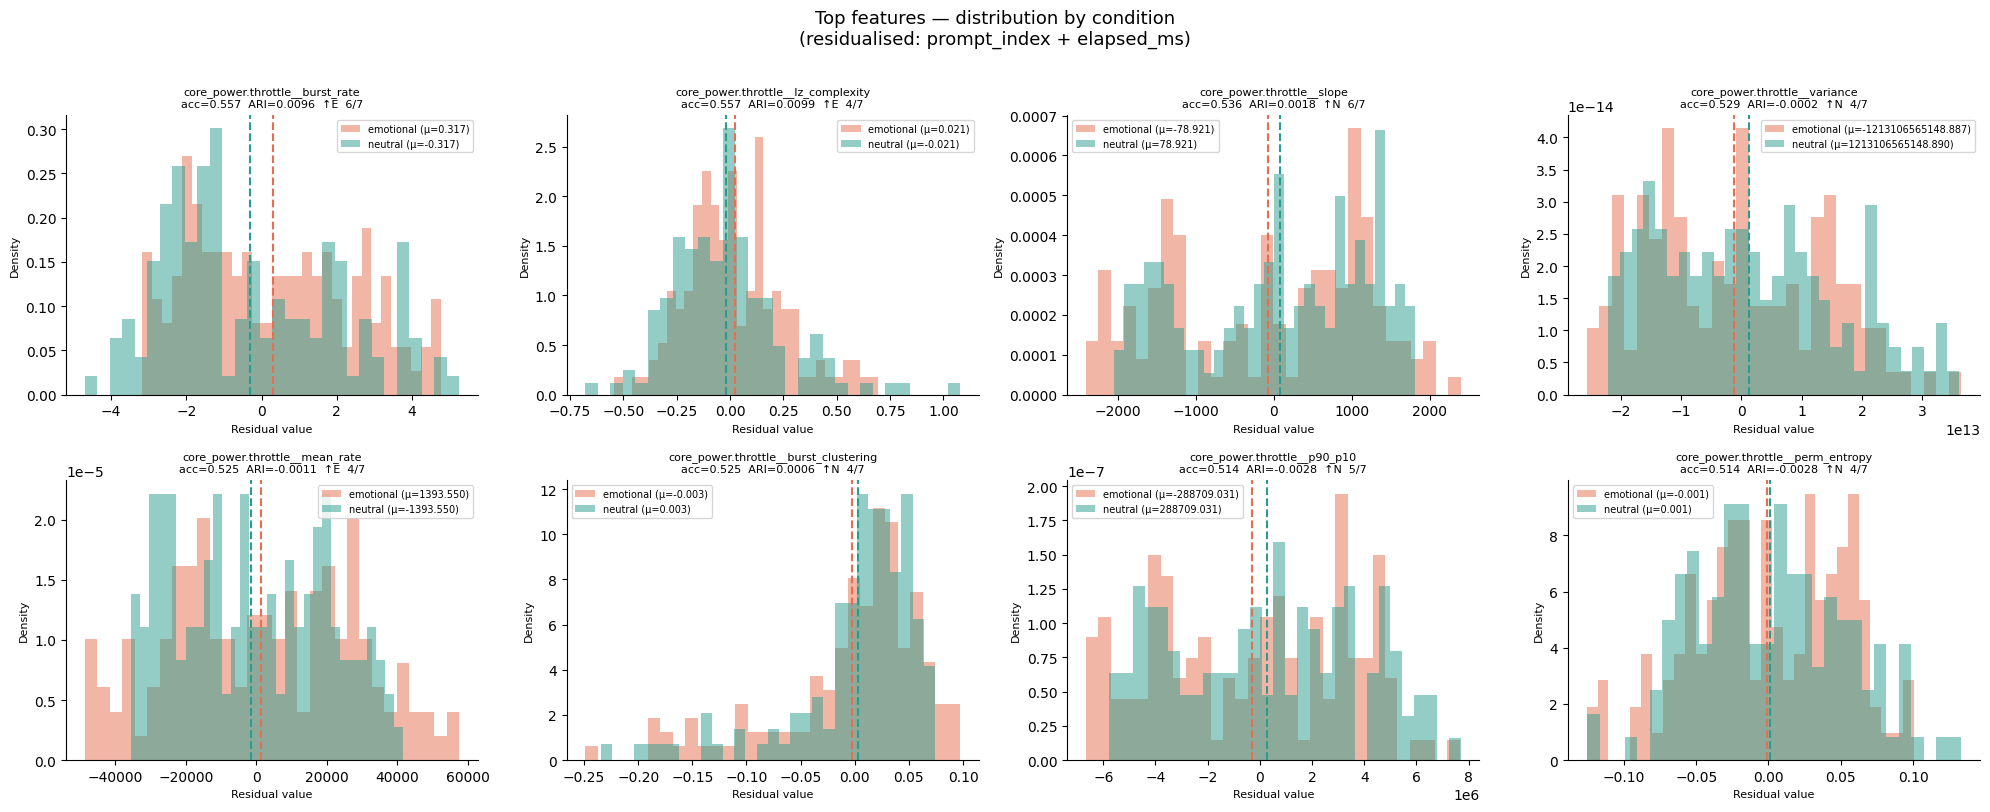

Saved: /Users/rsalvi/Desktop/mccviahat/results/hat_analysis/top_features_distribution_by_condition_70b.png

Mean (residual) by condition:
  Feature                                                   emotional     neutral        diff
  core_power.throttle__burst_rate                              0.3171     -0.3171      0.6343
  core_power.throttle__lz_complexity                           0.0210     -0.0210      0.0421
  core_power.throttle__slope                                 -78.9212     78.9212   -157.8424
  core_power.throttle__variance                            -1213106565148.8867  1213106565148.8896  -2426213130297.7764
  core_power.throttle__mean_rate                            1393.5497  -1393.5497   2787.0994
  core_power.throttle__burst_clustering                       -0.0029      0.0029     -0.0058
  core_power.throttle__p90_p10                             -288709.0307  288709.0307  -577418.0614
  core_power.throttle__perm_entropy                           -0.0008      0.00

In [ ]:
TOP_N = 8

top_feats = sf_resid.head(TOP_N)['feature'].tolist()

n_cols = 4
n_rows = (TOP_N + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_feats):
    ax = axes[i]
    for cond, color in [('emotional', '#e76f51'), ('neutral', '#2a9d8f')]:
        vals = X_l1_resid.loc[df_all['condition'] == cond, feat]
        e_mean = vals.mean()
        ax.hist(vals, bins=30, alpha=0.5, color=color, label=f'{cond} (μ={e_mean:.3f})', density=True)
        ax.axvline(e_mean, color=color, lw=1.5, ls='--')

    row = sf_resid[sf_resid.feature == feat].iloc[0]
    ax.set_title(
        f'{feat}\nacc={row.accuracy:.3f}  ARI={row.ari:.4f}  {row.direction}  {row.runs_majority}',
        fontsize=8
    )
    ax.set_xlabel('Residual value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)
    ax.spines[['top', 'right']].set_visible(False)

for j in range(len(top_feats), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Top features — distribution by condition\n(residualised: prompt_index + elapsed_ms)',
    fontsize=13, y=1.01
)
plt.tight_layout()
out = RESULT_DIR / 'top_features_distribution_by_condition_70b.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

# Also print summary stats per condition for each top feature
print('\nMean (residual) by condition:')
print(f'  {"Feature":55s}  {"emotional":>10}  {"neutral":>10}  {"diff":>10}')
for feat in top_feats:
    e_m = X_l1_resid.loc[df_all.condition == 'emotional', feat].mean()
    n_m = X_l1_resid.loc[df_all.condition == 'neutral',   feat].mean()
    print(f'  {feat:55s}  {e_m:10.4f}  {n_m:10.4f}  {e_m - n_m:10.4f}')